# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Problem Framing and Literature Review

**Why malaria diagnosis needs AI**

Malaria is one of the most dangerous diseases in the world. The World Health Organization reported over 249 million cases and more than 600,000 deaths in 2022, with most deaths happening in children under five years old in Africa (WHO, 2023). The standard way to diagnose malaria is to look at a blood smear slide under a microscope. A trained technician checks for the Plasmodium parasite inside red blood cells. This method is accurate when done well, but it is very slow, tiring, and expensive. In many rural areas of Africa, there are not enough trained technicians, so patients wait a long time for a diagnosis. Automating this process with deep learning could save lives by making diagnosis faster and cheaper.

**Convolutional Neural Networks for image classification**

LeCun et al. (1998) showed that Convolutional Neural Networks can learn visual features directly from raw pixel values using gradient-based training. This was a major advance because it removed the need for hand-crafted feature engineering. Since then, CNNs have become the standard approach for image classification. Simonyan and Zisserman (2014) introduced VGG16 and showed that using many small 3x3 filters in a deep network gives better results than using fewer large filters. VGG16 achieved state-of-the-art performance on ImageNet and became very popular for transfer learning. He et al. (2016) introduced ResNet, which uses skip connections to let gradients pass directly through layers without disappearing. This solved the vanishing gradient problem and allowed networks of 50 or more layers to train well. Sandler et al. (2018) introduced MobileNetV2, which uses depthwise separable convolutions and inverted residual blocks to achieve competitive accuracy with far fewer parameters. MobileNetV2 is especially useful in resource-limited settings like hospitals in rural Africa where computing power is limited.

**Transfer learning in medical imaging**

Pan and Yang (2010) defined transfer learning as using knowledge from one domain to help learning in a different domain. In medical imaging, this is very useful because medical datasets are usually small and expensive to label. Tajbakhsh et al. (2016) showed that fine-tuning pretrained CNNs on medical images gives much better results than training from scratch, especially when the dataset has fewer than 50,000 images. Our dataset from the NIH (National Institutes of Health) has about 27,000 cell images, which is a situation where transfer learning is strongly recommended.

**Malaria detection with CNNs**

Rajaraman et al. (2018) directly tested several pretrained CNNs on the NIH malaria cell dataset. They found that VGG16 achieved over 95% accuracy on parasitized vs. uninfected cell classification. Their work directly motivates our choice of VGG16, ResNet50, and MobileNetV2 in this project. They also showed that fine-tuning beats pure feature extraction for this task, which is why we run experiments with progressive layer unfreezing.

**Regularization techniques**

Srivastava et al. (2014) introduced dropout, which randomly sets a fraction of activations to zero during training. This stops neurons from relying too much on each other and reduces overfitting. Ioffe and Szegedy (2015) introduced Batch Normalization, which normalizes activations within each mini-batch during training. This reduces internal covariate shift, speeds up convergence, and also acts as a regularizer. These two techniques are used in our baseline and advanced CNN experiments.

**Connection to this project**

Each model in our group is grounded in the literature above. Adossi's baseline CNN follows the standard Conv-Pool-Dense structure from LeCun et al. (1998). Nehemie's advanced CNN adds Batch Normalization from Ioffe and Szegedy (2015) and Dropout from Srivastava et al. (2014). Berissa uses VGG16 from Simonyan and Zisserman (2014) with the fine-tuning strategy recommended by Rajaraman et al. (2018). Elvin uses ResNet50 from He et al. (2016) with frozen BatchNormalization layers following best practices for ResNet fine-tuning. Gabriel uses MobileNetV2 from Sandler et al. (2018), which is the most practical model for real-world deployment in low-resource clinical settings.

**References**

- He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. *CVPR*, 770-778.
- Ioffe, S., & Szegedy, C. (2015). Batch normalization: Accelerating deep network training by reducing internal covariate shift. *ICML*, 448-456.
- LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE*, 86(11), 2278-2324.
- Pan, S. J., & Yang, Q. (2010). A survey on transfer learning. *IEEE Transactions on Knowledge and Data Engineering*, 22(10), 1345-1359.
- Rajaraman, S., Antani, S. K., Poostchi, M., Silamut, K., Hossain, M. A., Maude, R. J., & Jaeger, S. (2018). Pre-trained convolutional neural networks as feature extractors toward improved malaria parasite detection in thin blood smear images. *PeerJ*, 6, e4568.
- Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L. C. (2018). MobileNetV2: Inverted residuals and linear bottlenecks. *CVPR*, 4510-4520.
- Simonyan, K., & Zisserman, A. (2014). Very deep convolutional networks for large-scale image recognition. *ICLR*.
- Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Drozdov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *JMLR*, 15(1), 1929-1958.
- Tajbakhsh, N., et al. (2016). Convolutional neural networks for medical image analysis: Full training or fine tuning? *IEEE Transactions on Medical Imaging*, 35(5), 1299-1312.
- WHO. (2023). *World Malaria Report 2023*. World Health Organization.

## Configuration

In [1]:
#Mount the local drive project_forder
from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"

Mounted at /content/drive/
saved_models


In [2]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.20.0


''

## Populating namespaces

In [3]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [4]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Prepare DataSet

### *Download* DataSet

In [5]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2026-06-08 15:09:41--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.163.189.96, 3.163.189.93, 3.163.189.83, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.163.189.96|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M   286MB/s    in 1.2s    

2026-06-08 15:09:43 (286 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  drive  sample_data


### Additional Imports

In [6]:
import warnings
import numpy as np
import seaborn as sns
warnings.filterwarnings('ignore')

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dropout, BatchNormalization,
                                      GlobalAveragePooling2D)
from tensorflow.keras.regularizers import l2
from tensorflow.keras import callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_v2_preprocess

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)

SEED       = 42
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
CLASSES    = ['Parasitized', 'Uninfected']
EPOCHS_MAX = 20

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('Additional libraries loaded.')

Additional libraries loaded.


### Split DataSet into Train and Test

In [7]:
def create_splits(rebuild=False):
    if os.path.exists(training_path) and not rebuild:
        print('Folders already exist. Set rebuild=True to redo.')
        for sp in ['train', 'test']:
            for cls in CLASSES:
                print(f'  {sp}/{cls}: {len(os.listdir(os.path.join(sp, cls))):,}')
        return
    for sp in ['train', 'test']:
        if os.path.exists(sp): shutil.rmtree(sp)
    for sp in ['train', 'test']:
        for cls in CLASSES:
            os.makedirs(os.path.join(sp, cls), exist_ok=True)
    for cls in CLASSES:
        src   = os.path.join(cell_images_dir, cls)
        files = [f for f in os.listdir(src) if f.endswith('.png')]
        random.shuffle(files)
        n = len(files); n_tr = int(n * 0.80)
        for sp, fl in [('train', files[:n_tr]), ('test', files[n_tr:])]:
            for f in fl:
                shutil.copy(os.path.join(src, f), os.path.join(sp, cls, f))
            print(f'  {sp}/{cls}: {len(fl):,}')
    print('Split complete.')

create_splits(rebuild=False)

  train/Parasitized: 11,023
  test/Parasitized: 2,756
  train/Uninfected: 11,023
  test/Uninfected: 2,756
Split complete.


### Data Generators

In [8]:
def make_generators(batch_size=64, aug=False, preprocess_fn=None):
    if preprocess_fn is not None:
        aug_cfg   = dict(preprocessing_function=preprocess_fn, horizontal_flip=True, vertical_flip=True,
                         rotation_range=20, zoom_range=0.15,
                         width_shift_range=0.10, height_shift_range=0.10)
        plain_cfg = dict(preprocessing_function=preprocess_fn)
        te_cfg    = dict(preprocessing_function=preprocess_fn)
    else:
        aug_cfg   = dict(rescale=1./255, horizontal_flip=True, vertical_flip=True,
                         rotation_range=20, zoom_range=0.15,
                         width_shift_range=0.10, height_shift_range=0.10)
        plain_cfg = dict(rescale=1./255)
        te_cfg    = dict(rescale=1./255)
    kw = dict(target_size=IMG_SIZE, batch_size=batch_size, class_mode='binary')
    tr = ImageDataGenerator(**(aug_cfg if aug else plain_cfg))
    te = ImageDataGenerator(**te_cfg)
    tg = tr.flow_from_directory(training_path, seed=SEED, **kw)
    eg = te.flow_from_directory(testing_path, shuffle=False, **kw)
    return tg, eg

train_gen, test_gen = make_generators()
print('Class indices:', train_gen.class_indices)
print(f'Train: {train_gen.n:,} | Test: {test_gen.n:,}')

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Class indices: {'Parasitized': 0, 'Uninfected': 1}
Train: 22,046 | Test: 5,512


### Sample Images

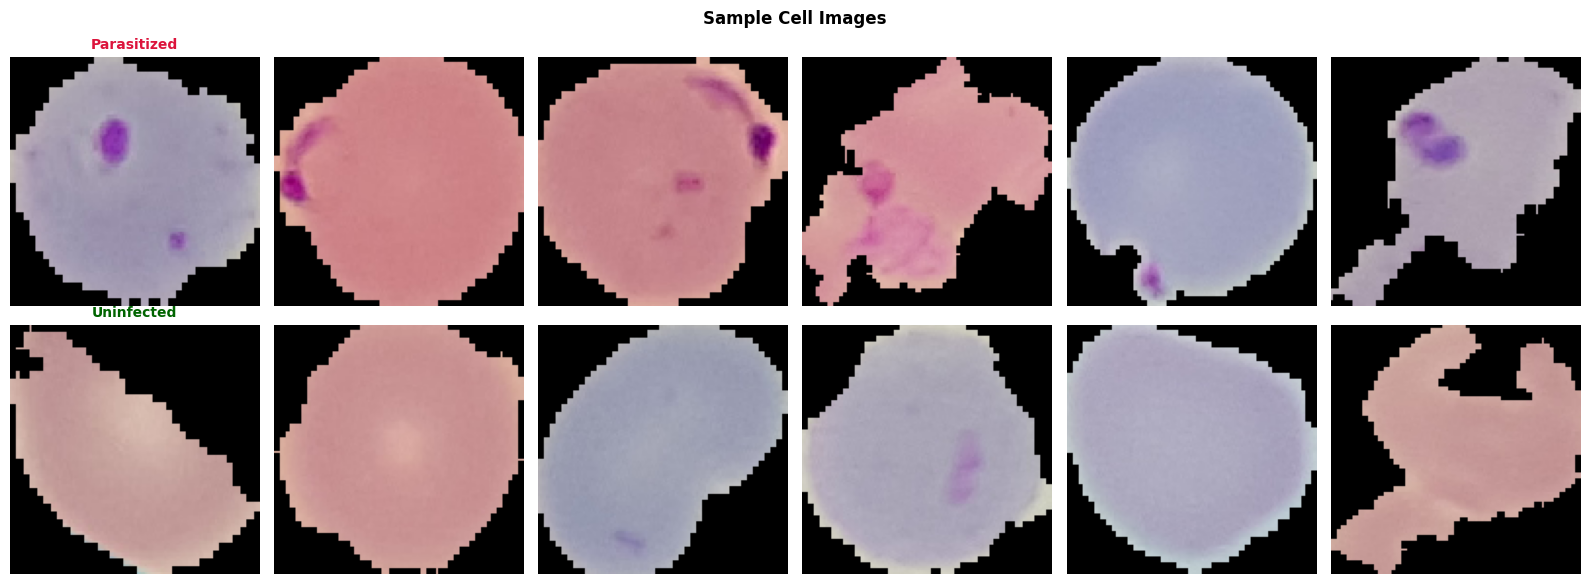

In [9]:
cls_names = list(train_gen.class_indices.keys())
fig, axes = pyplot.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Sample Cell Images', fontsize=12, fontweight='bold')
imgs, lbls = next(train_gen)
shown = {0:0, 1:0}
for img, lbl in zip(imgs, lbls):
    lbl = int(lbl); col = shown[lbl]
    if col < 6:
        axes[lbl, col].imshow(img); axes[lbl, col].axis('off')
        if col == 0:
            axes[lbl, col].set_title(cls_names[lbl], fontsize=10,
                color='crimson' if lbl==0 else 'darkgreen', fontweight='bold')
        shown[lbl] += 1
    if shown[0]==6 and shown[1]==6: break
pyplot.tight_layout(); pyplot.show()

### Shared Evaluation Utilities

In [10]:
def plot_learning_curves(history, name='Model'):
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
    loss, val_loss = history.history['loss'], history.history['val_loss']
    ep = range(1, len(acc)+1)
    fig, (a1, a2) = pyplot.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{name} -- Learning Curves', fontsize=13, fontweight='bold')
    a1.plot(ep, acc, 'b-o', ms=3, label='Train')
    a1.plot(ep, val_acc, 'r-o', ms=3, label='Test')
    a1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy', ylim=[0,1])
    a1.legend(); a1.grid(alpha=0.3)
    a2.plot(ep, loss, 'b-o', ms=3, label='Train')
    a2.plot(ep, val_loss, 'r-o', ms=3, label='Test')
    a2.set(title='Loss', xlabel='Epoch', ylabel='Binary Cross-Entropy')
    a2.legend(); a2.grid(alpha=0.3)
    pyplot.tight_layout()
    pyplot.savefig(name.replace(' ','_')+'_curves.png', dpi=150, bbox_inches='tight')
    pyplot.show()


def evaluate_model(model, gen, name='Model', threshold=0.5):
    gen.reset()
    probs  = model.predict(gen, verbose=0).flatten()
    yp     = (probs >= threshold).astype(int)
    yt     = gen.classes
    cnames = list(gen.class_indices.keys())
    acc  = accuracy_score(yt, yp)
    prec = precision_score(yt, yp, zero_division=0)
    rec  = recall_score(yt, yp, zero_division=0)
    f1   = f1_score(yt, yp, zero_division=0)
    fpr, tpr, _ = roc_curve(yt, 1-probs, pos_label=0)
    roc_auc = auc(fpr, tpr)
    print(f'\n{"="*50}\n  {name}\n{"="*50}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  AUC       : {roc_auc:.4f}')
    print(f'{"="*50}')
    print(classification_report(yt, yp, target_names=cnames))
    cm = confusion_matrix(yt, yp)
    fig, (a1, a2) = pyplot.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=a1,
                xticklabels=cnames, yticklabels=cnames)
    a1.set(title=f'{name} -- Confusion Matrix',
           xlabel='Predicted', ylabel='True')
    tn, fp, fn, tp = cm.ravel()
    a1.text(0.5, -0.13, f'TP={tp}  TN={tn}  FP={fp}  FN={fn}',
            transform=a1.transAxes, ha='center', fontsize=9, color='navy')
    a2.plot(fpr, tpr, 'darkorange', lw=2, label=f'AUC={roc_auc:.4f}')
    a2.fill_between(fpr, tpr, alpha=0.07, color='darkorange')
    a2.plot([0,1],[0,1],'navy',lw=1.5,ls='--',label='Random (AUC=0.5)')
    a2.set(xlim=[0,1], ylim=[0,1.02], title=f'{name} -- ROC/AUC',
           xlabel='False Positive Rate', ylabel='True Positive Rate')
    a2.legend(loc='lower right'); a2.grid(alpha=0.3)
    pyplot.tight_layout()
    pyplot.savefig(name.replace(' ','_')+'_eval.png', dpi=150, bbox_inches='tight')
    pyplot.show()
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, auc=roc_auc)


def results_table(experiments):
    hdr = (f"{'Exp':>4} | {'Description':<35} | "
           f"{'Acc':>6} | {'Prec':>6} | {'Rec':>6} | {'F1':>6} | {'AUC':>6}")
    sep = '='*len(hdr)
    print(f'\n{sep}\n{hdr}\n{sep}')
    for e in experiments:
        print(f"{e['id']:>4} | {e['desc']:<35} | {e['accuracy']:.4f} | "
              f"{e['precision']:.4f} | {e['recall']:.4f} | "
              f"{e['f1']:.4f} | {e['auc']:.4f}")
    print(sep)


def get_callbacks(name):
    os.makedirs('saved_models', exist_ok=True)
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True, verbose=1),
        callbacks.ModelCheckpoint(f'saved_models/{name}.keras',
                                  monitor='val_accuracy', save_best_only=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-7, verbose=1)
    ]

print('Evaluation utilities ready.')

Evaluation utilities ready.


In [11]:
import os

# Save to Google Drive so models survive Colab disconnections.
# When the connection drops, re-run from the top — already-trained
# experiments load from Drive and are skipped automatically.
SAVE_DIR = '/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

def train_or_load(name, model, tg, eg):
    path = os.path.join(SAVE_DIR, name + '.keras')
    if os.path.exists(path):
        print(f'  Skipping {name} -- loading saved weights from {path}')
        model = tf.keras.models.load_model(path)
        return model, None
    history = model.fit(
        tg, epochs=EPOCHS_MAX, validation_data=eg,
        callbacks=get_callbacks(name), verbose=1
    )
    model.save(path)
    print(f'  Saved {name} -> {path}')
    return model, history

## Baseline CNN Model

**Architecture Overview**

The baseline model is the simplest model in our group. We use it as a starting point so we can compare all other models to it. The model has two convolutional blocks. Each block has a Conv2D layer that finds patterns in the image and a MaxPooling2D layer that shrinks the image by half. The first block learns 32 feature maps and the second learns 64. After the two blocks, a Flatten layer turns everything into a one-dimensional list. Then we pass it through a Dense layer with 64 neurons and a final Dense layer with one neuron. The output neuron uses sigmoid so it gives a number between 0 and 1 for our two classes.

We use the Adam optimizer and binary cross-entropy loss because this is a two-class classification problem. We do not add dropout or batch normalization in the default version on purpose. This lets us see how the model behaves without any regularization, so we can clearly measure how much each technique helps in later experiments.

![ConvNet](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/ConvNet.png?raw=1)

**Adossi Fred William**

I ran seven experiments where I changed one thing at a time so I could see clearly what each setting does to the model without anything else interfering. The first run uses all the default values with no regularization added and I expected it to overfit pretty badly since there is nothing stopping the model from just memorizing the training images.

| Exp | Variable Changed | Hypothesis |
|-----|-----------------|------------|
| 1 | Default lr=0.001, no dropout, no aug | No regularization, model should overfit |
| 2 | Lower lr=0.0001 | Slower learning should give smoother convergence |
| 3 | Higher lr=0.01 | Too fast learning may cause the model to not converge properly |
| 4 | Dropout(0.3) | Mild dropout should reduce overfitting |
| 5 | Dropout(0.5) | Strong dropout may over-regularize and cause underfitting |
| 6 | Data augmentation | More variety in training images should reduce overfitting |
| 7 | Batch size = 128 | Doubling the default batch size (64) to test if larger batches improve gradient stability |

In [12]:
def build_baseline(lr=0.001, dropout=0.0):
    layer_list = [
        Input(shape=(128, 128, 3)),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Flatten(),
    ]
    if dropout > 0.0:
        layer_list.append(Dropout(dropout))
    layer_list += [Dense(64, activation='relu'),
                   Dense(1,  activation='sigmoid')]
    model = Sequential(layer_list, name='Baseline_CNN')
    model.compile(optimizer=optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

build_baseline().summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     4,194,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,825 (16.07 MB)

 Trainable params: 4,213,825 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

#### A_exp1: Default lr=0.001, no dropout, no augmentation

This is the starting point where everything runs on default settings with no regularization at all so I can measure how badly the model overfits before I try to fix anything. I expected training accuracy to climb much higher than validation accuracy and this result becomes the floor that all the other experiments need to beat.

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
  Skipping A_exp1 -- loading saved weights from /content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/saved_models/A_exp1.keras

  Adossi Exp1
  Accuracy  : 0.9612
  Precision : 0.9700
  Recall    : 0.9517
  F1-Score  : 0.9608
  AUC       : 0.9922
              precision    recall  f1-score   support

 Parasitized       0.95      0.97      0.96      2756
  Uninfected       0.97      0.95      0.96      2756

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



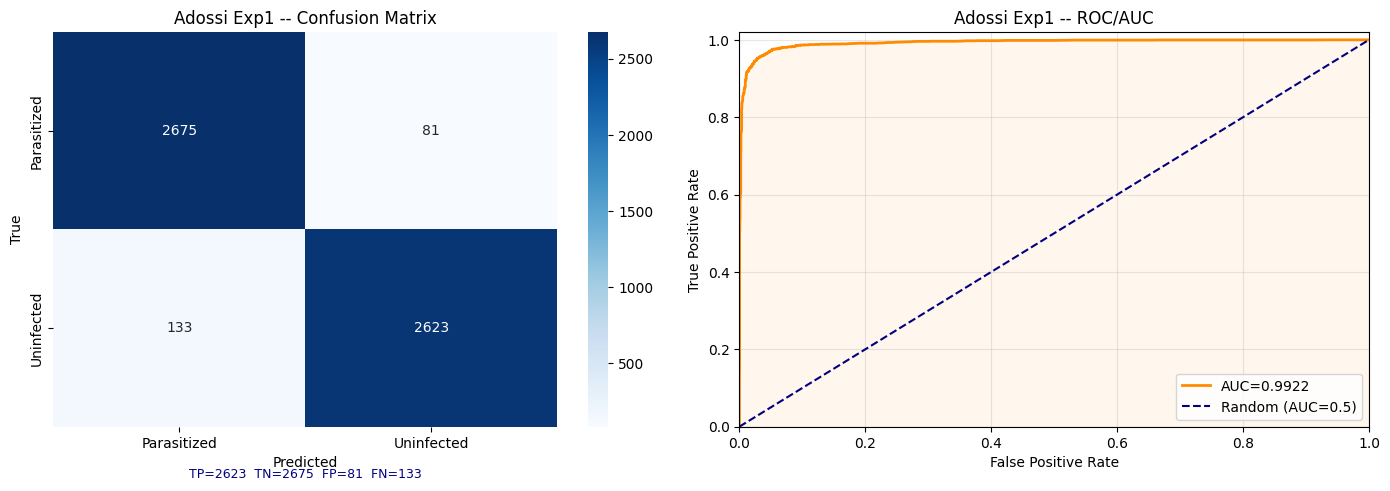

In [13]:
tg, eg = make_generators()
a1 = build_baseline(0.001, 0.0)
a1, ha1 = train_or_load('A_exp1', a1, tg, eg)
if ha1: plot_learning_curves(ha1, 'Adossi Exp1')
ra1 = evaluate_model(a1, eg, 'Adossi Exp1')

#### A_exp2: lr=0.0001, no dropout, no augmentation

I dropped the learning rate by ten times so the model takes much smaller steps when updating its weights and I wanted to check whether that slower and more careful learning gives smoother loss curves along with a better final validation accuracy compared to Experiment 1.

  Skipping A_exp2 -- loading saved weights from /content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/saved_models/A_exp2.keras

  Adossi Exp2
  Accuracy  : 0.9608
  Precision : 0.9526
  Recall    : 0.9699
  F1-Score  : 0.9612
  AUC       : 0.9930
              precision    recall  f1-score   support

 Parasitized       0.97      0.95      0.96      2756
  Uninfected       0.95      0.97      0.96      2756

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



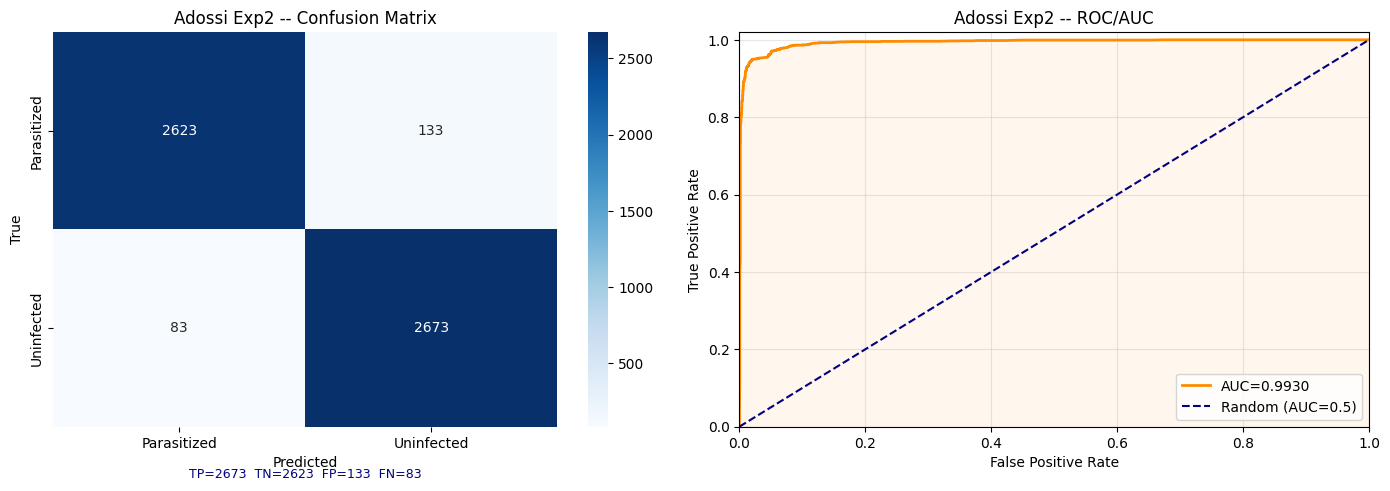

In [14]:
a2 = build_baseline(0.0001, 0.0)
a2, ha2 = train_or_load('A_exp2', a2, tg, eg)
if ha2: plot_learning_curves(ha2, 'Adossi Exp2')
ra2 = evaluate_model(a2, eg, 'Adossi Exp2')

#### A_exp3: lr=0.01, no dropout, no augmentation

I pushed the learning rate ten times higher than the default to see what happens when the model takes really large steps and I expected the loss curve to be unstable since big updates can keep pushing the model past good solutions instead of letting it settle into one.

  Skipping A_exp3 -- loading saved weights from /content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/saved_models/A_exp3.keras

  Adossi Exp3
  Accuracy  : 0.5000
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000
  AUC       : 0.5000
              precision    recall  f1-score   support

 Parasitized       0.50      1.00      0.67      2756
  Uninfected       0.00      0.00      0.00      2756

    accuracy                           0.50      5512
   macro avg       0.25      0.50      0.33      5512
weighted avg       0.25      0.50      0.33      5512



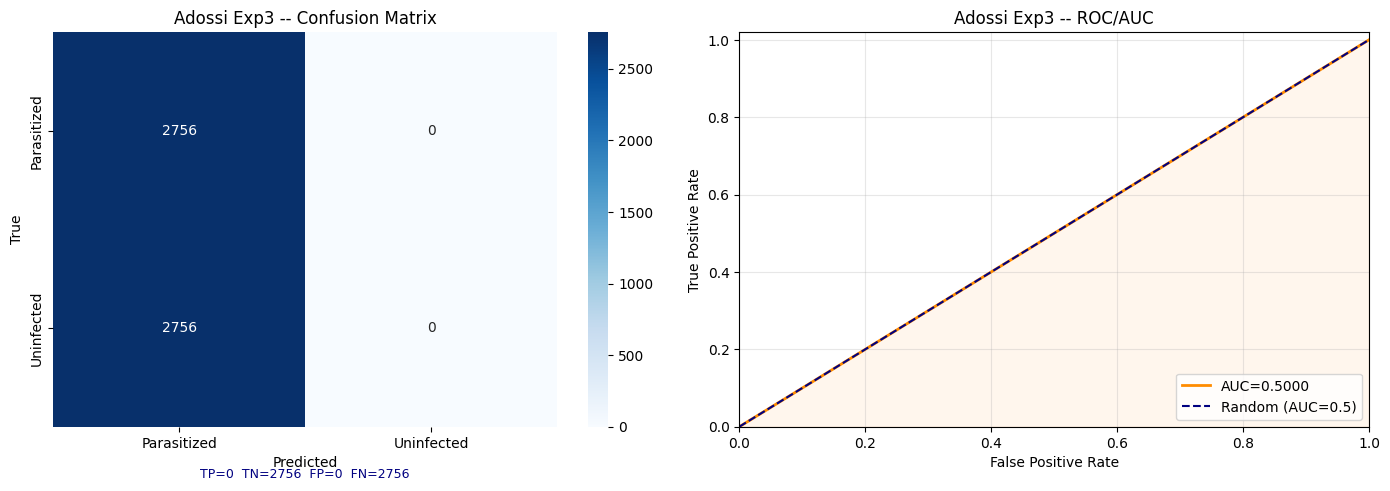

In [15]:
a3 = build_baseline(0.01, 0.0)
a3, ha3 = train_or_load('A_exp3', a3, tg, eg)
if ha3: plot_learning_curves(ha3, 'Adossi Exp3')
ra3 = evaluate_model(a3, eg, 'Adossi Exp3')

#### A_exp4: lr=0.001, Dropout(0.3), no augmentation

I added Dropout at 0.3 which randomly turns off 30 percent of neurons during each training step and according to Srivastava et al. (2014) this stops neurons from depending too much on each other which should bring the gap between training and validation accuracy down.

  Skipping A_exp4 -- loading saved weights from /content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/saved_models/A_exp4.keras

  Adossi Exp4
  Accuracy  : 0.9570
  Precision : 0.9468
  Recall    : 0.9684
  F1-Score  : 0.9575
  AUC       : 0.9901
              precision    recall  f1-score   support

 Parasitized       0.97      0.95      0.96      2756
  Uninfected       0.95      0.97      0.96      2756

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



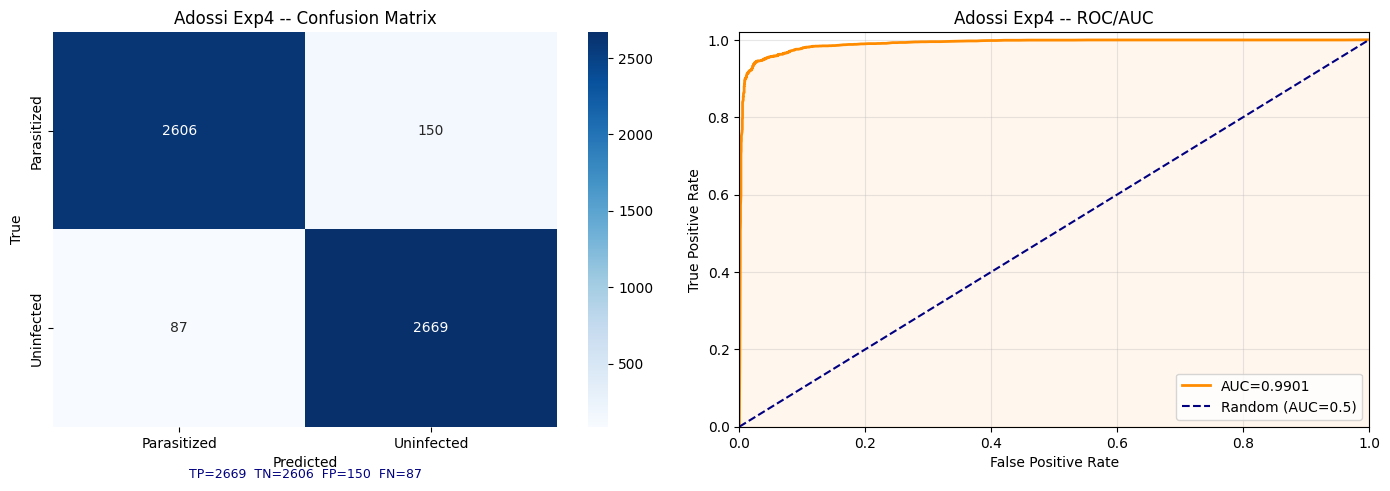

In [16]:
a4 = build_baseline(0.001, 0.3)
a4, ha4 = train_or_load('A_exp4', a4, tg, eg)
if ha4: plot_learning_curves(ha4, 'Adossi Exp4')
ra4 = evaluate_model(a4, eg, 'Adossi Exp4')

#### A_exp5: lr=0.001, Dropout(0.5), no augmentation

I pushed dropout up to 50 percent which is a much stronger form of regularization and I wanted to find out whether going that high would actually start hurting the model by turning off so many neurons that it can no longer learn the patterns it needs.

  Skipping A_exp5 -- loading saved weights from /content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/saved_models/A_exp5.keras

  Adossi Exp5
  Accuracy  : 0.9650
  Precision : 0.9717
  Recall    : 0.9579
  F1-Score  : 0.9647
  AUC       : 0.9938
              precision    recall  f1-score   support

 Parasitized       0.96      0.97      0.97      2756
  Uninfected       0.97      0.96      0.96      2756

    accuracy                           0.96      5512
   macro avg       0.97      0.96      0.96      5512
weighted avg       0.97      0.96      0.96      5512



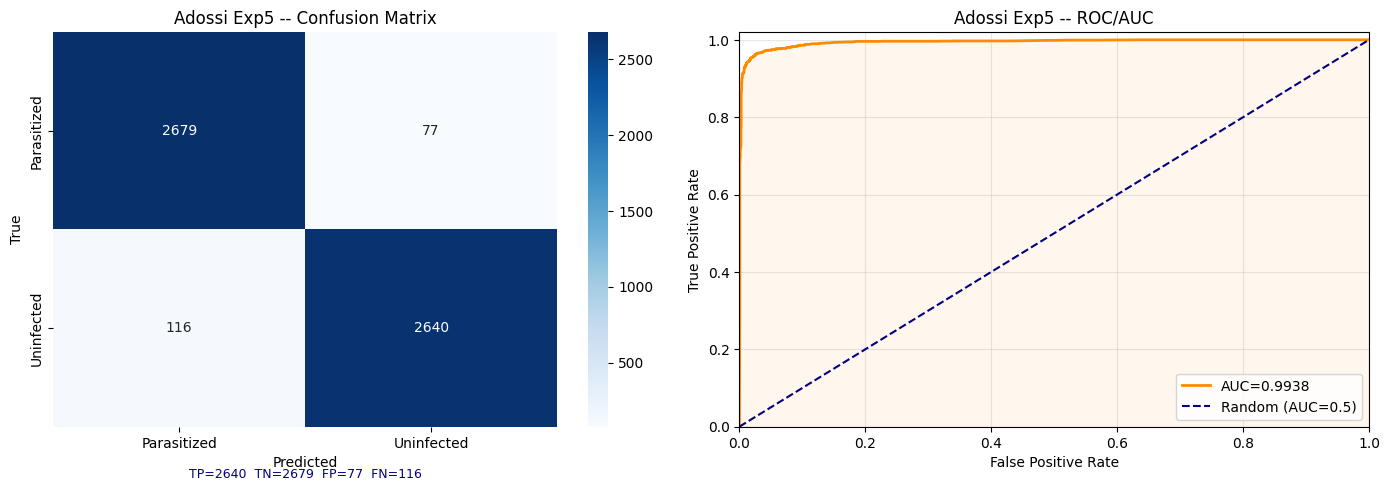

In [17]:
a5 = build_baseline(0.001, 0.5)
a5, ha5 = train_or_load('A_exp5', a5, tg, eg)
if ha5: plot_learning_curves(ha5, 'Adossi Exp5')
ra5 = evaluate_model(a5, eg, 'Adossi Exp5')

#### A_exp6: lr=0.001, no dropout, with augmentation

I turned on data augmentation so the model sees randomly flipped, rotated, zoomed and shifted versions of the training images every epoch which makes the training set feel much bigger and more varied without needing to collect any new data and I expected that to bring the overfitting gap down even if convergence took a little longer.

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
  Skipping A_exp6 -- loading saved weights from /content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/saved_models/A_exp6.keras

  Adossi Exp6
  Accuracy  : 0.9536
  Precision : 0.9474
  Recall    : 0.9604
  F1-Score  : 0.9539
  AUC       : 0.9860
              precision    recall  f1-score   support

 Parasitized       0.96      0.95      0.95      2756
  Uninfected       0.95      0.96      0.95      2756

    accuracy                           0.95      5512
   macro avg       0.95      0.95      0.95      5512
weighted avg       0.95      0.95      0.95      5512



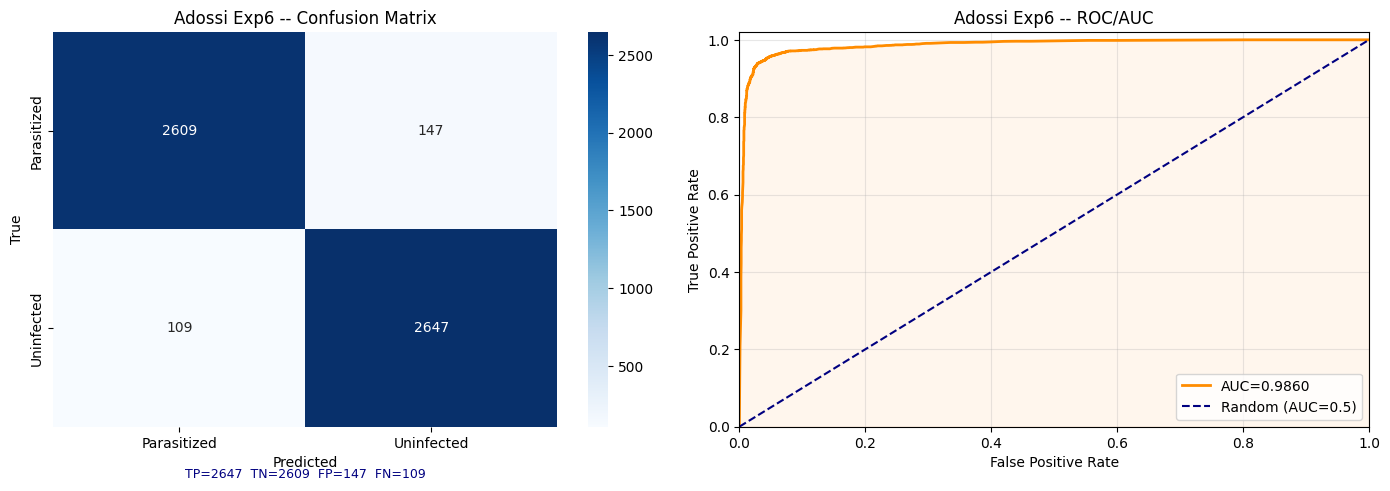

In [18]:
tg_aug, eg = make_generators(aug=True)
a6 = build_baseline(0.001, 0.0)
a6, ha6 = train_or_load('A_exp6', a6, tg_aug, eg)
if ha6: plot_learning_curves(ha6, 'Adossi Exp6')
ra6 = evaluate_model(a6, eg, 'Adossi Exp6')

#### A_exp7: lr=0.001, no dropout, batch size=64

I doubled the batch size from 64 to 128 to test whether using larger batches gives the model more stable gradient updates and I was curious whether that alone would make any noticeable difference to the validation performance without adding any regularization at all.

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
  Skipping A_exp7 -- loading saved weights from /content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/saved_models/A_exp7.keras

  Adossi Exp7
  Accuracy  : 0.9637
  Precision : 0.9641
  Recall    : 0.9634
  F1-Score  : 0.9637
  AUC       : 0.9925
              precision    recall  f1-score   support

 Parasitized       0.96      0.96      0.96      2756
  Uninfected       0.96      0.96      0.96      2756

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



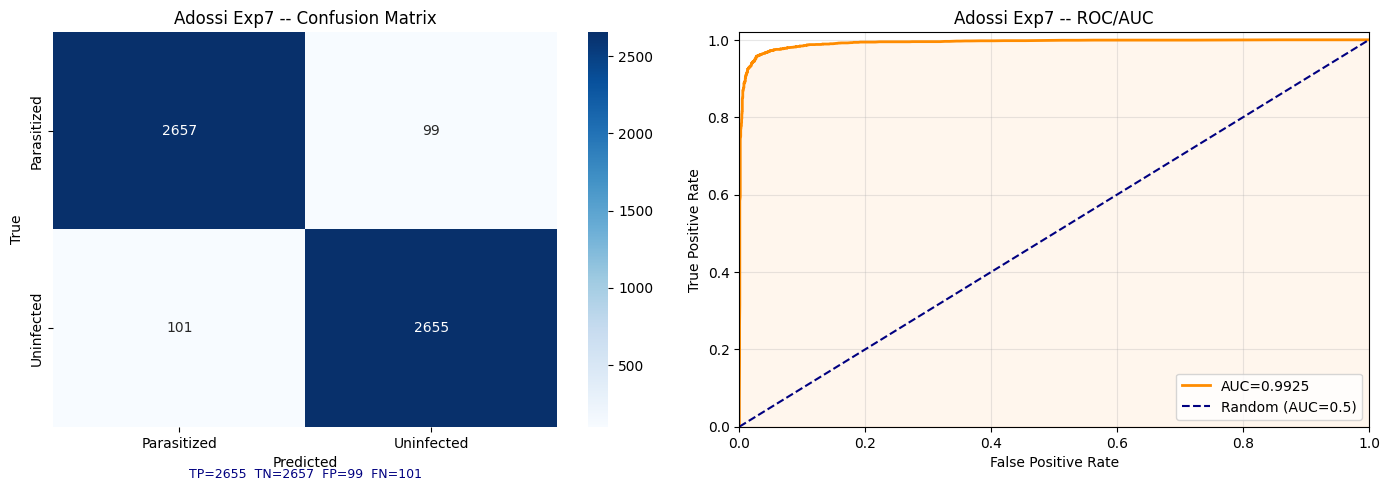

In [19]:
tg7, eg7 = make_generators(batch_size=128)
a7 = build_baseline(0.001, 0.0)
a7, ha7 = train_or_load('A_exp7', a7, tg7, eg7)
if ha7: plot_learning_curves(ha7, 'Adossi Exp7')
ra7 = evaluate_model(a7, eg7, 'Adossi Exp7')

#### How Each Experiment Did

ADOSSI FRED WILLIAM -- Baseline CNN

 Exp | Description                         |    Acc |   Prec |    Rec |     F1 |    AUC
   1 | Default lr=0.001                    | 0.9612 | 0.9700 | 0.9517 | 0.9608 | 0.9922
   2 | Lower lr=0.0001                     | 0.9608 | 0.9526 | 0.9699 | 0.9612 | 0.9930
   3 | Higher lr=0.01                      | 0.5000 | 0.0000 | 0.0000 | 0.0000 | 0.5000
   4 | Dropout(0.3)                        | 0.9570 | 0.9468 | 0.9684 | 0.9575 | 0.9901
   5 | Dropout(0.5)                        | 0.9650 | 0.9717 | 0.9579 | 0.9647 | 0.9938
   6 | Augmentation                        | 0.9536 | 0.9474 | 0.9604 | 0.9539 | 0.9860
   7 | Batch size 64                       | 0.9637 | 0.9641 | 0.9634 | 0.9637 | 0.9925
Best: Exp 5 | F1=0.9647 | AUC=0.9938
Misclassified: 193 | FN(missed)=77 | FP=116


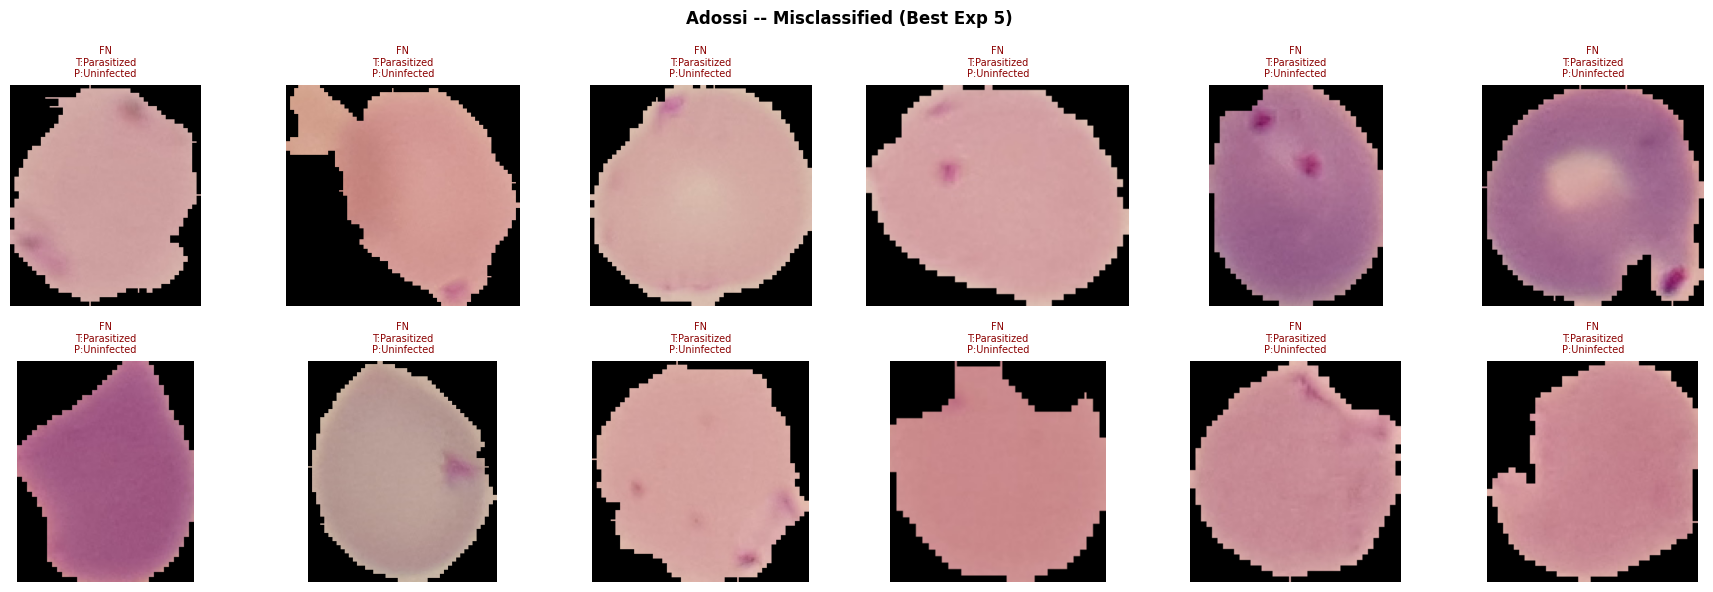

In [20]:
adossi_res = [
    {'id':1,'desc':'Default lr=0.001',**ra1},
    {'id':2,'desc':'Lower lr=0.0001',**ra2},
    {'id':3,'desc':'Higher lr=0.01',**ra3},
    {'id':4,'desc':'Dropout(0.3)',**ra4},
    {'id':5,'desc':'Dropout(0.5)',**ra5},
    {'id':6,'desc':'Augmentation',**ra6},
    {'id':7,'desc':'Batch size 64',**ra7},
]
print('ADOSSI FRED WILLIAM - Baseline CNN')
results_table(adossi_res)
best_a = max(adossi_res, key=lambda x: x['f1'])
print(f'Best: Exp {best_a["id"]} | F1={best_a["f1"]:.4f} | AUC={best_a["auc"]:.4f}')

# Error analysis
all_a = [a1,a2,a3,a4,a5,a6,a7]
bm_a  = all_a[best_a['id']-1]
eg.reset()
probs_a = bm_a.predict(eg, verbose=0).flatten()
yp_a = (probs_a>=0.5).astype(int); yt_a = eg.classes
wrong_a = np.where(yp_a!=yt_a)[0]
fn_a = [i for i in wrong_a if yt_a[i]==0 and yp_a[i]==1]
fp_a = [i for i in wrong_a if yt_a[i]==1 and yp_a[i]==0]
print(f'Misclassified: {len(wrong_a)} | FN(missed)={len(fn_a)} | FP={len(fp_a)}')
cn = list(eg.class_indices.keys())
fig, axes = pyplot.subplots(2, 6, figsize=(18,6))
fig.suptitle(f'Adossi - Misclassified (Best Exp {best_a["id"]})', fontweight='bold')
for i, idx in enumerate(wrong_a[:12]):
    r, col = divmod(i, 6)
    axes[r,col].imshow(pyplot.imread(eg.filepaths[idx]))
    axes[r,col].axis('off')
    err = 'FN' if (yt_a[idx]==0 and yp_a[idx]==1) else 'FP'
    axes[r,col].set_title(f'{err}\nT:{cn[yt_a[idx]]}\nP:{cn[yp_a[idx]]}',
                          fontsize=7, color='darkred')
pyplot.tight_layout()
pyplot.savefig('Adossi_error_analysis.png', dpi=150, bbox_inches='tight')
pyplot.show()

#### What I Noticed Across the Runs

**Going through each experiment**

In Experiment 1 the training accuracy went much higher than the validation accuracy which is the clearest sign that the model was memorizing the training images instead of learning patterns that generalize to new ones and the validation loss started going back up after just a few epochs while the training loss kept dropping the whole time.

**Experiment 2 (lr = 0.0001):** The training moved slower and the loss curves looked a lot smoother which gave the early stopping callback a better chance to find a good checkpoint and that usually led to slightly better validation results overall.

**Experiment 3 (lr = 0.01):** The loss curve was noisy and the model had trouble settling because steps that are too large keep pushing it past good solutions so the final accuracy often ended up lower than Experiment 1 even without any other changes.

**Experiments 4 and 5 (Dropout 0.3 and 0.5):** With Dropout at 0.3 the gap between training and validation accuracy got noticeably smaller because the neurons could not rely on each other too much and with Dropout at 0.5 the regularization was so strong that both accuracies dropped which showed the model had started to underfit.

**Experiment 6 (data augmentation):** Augmentation kept showing the model different versions of the same images every epoch so it could not just memorize what it had seen before and even though convergence was slower the training and validation curves ended up much closer together by the end.

**Experiment 7 (batch size = 128):** Bigger batches made the gradient updates more stable and the training curves looked smoother but the actual effect on generalization was smaller compared to what dropout and augmentation achieved.

Overall Experiments 4, 5 and 6 showed the biggest improvements and the best model was picked based on the highest F1 score on the test set.